# Standalone FKPTJAX MG multipoles

This notebook uses only `fkptjax` APIs to:

1. build FKPT/FOLPS tables for an MG rescaling-branch example,
2. pass those tables through the FOLPS RSD path wrapped by `fkptjax.rsd`,
3. project to multipoles,
4. compare the explicit table route against `fkptjax.pipelines.rescale_branch_poles`,
5. compare an MG point against GR,
6. compare `P_ell` across EdS / fkPT-approximated beyond-EdS / full-kernel beyond-EdS kernels for HDKI/mu_OmDE, Hu-Sawicki f(R), and PHENOM/binning (redshift-only and redshift+scale) via the direct `Kfuncs_to_tables_jax` route.

Important: this notebook assumes `src/fkptjax/pipelines.py` has the corrected split:

```python
table = tuple(table_w)
table_now_terms = tuple(table_now)
```

It intentionally does **not** define `make_table_state_fixed()` anymore, to avoid shadowing the package implementation.

In [1]:
# Environment and path setup
import os
import sys
from pathlib import Path

os.environ.setdefault("FOLPS_BACKEND", "jax")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

# Make this notebook work from either repo root or examples/.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
for root in candidates:
    src = root / "src"
    if (src / "fkptjax").exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
        print(f"Added to sys.path: {src}")
        break

print("cwd:", cwd)
print("python:", sys.executable)


cwd: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/examples
python: /n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/bin/python


In [15]:
# Imports and pipeline split sanity check
import time
import inspect
import importlib
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from fkptjax.kfuncs_to_tables import build_jax_static_ctx, Kfuncs_to_tables_rescale_jax
import fkptjax.pipelines as pipelines
importlib.reload(pipelines)

from fkptjax.pipelines import make_table_state, rescale_branch_poles
from fkptjax.rsd import pack_fkpt_bias, tables_to_pkmu, project_to_poles

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())
print("fkptjax.pipelines file:", pipelines.__file__)
print("\nCurrent split_folps_tables source:\n")
print(inspect.getsource(pipelines.split_folps_tables))

# Quick guard: the fixed split must preserve the full raw table, including k at index 0.
_tw = tuple(range(30))
_tn = tuple(range(32))
_table, _table_now, _, _ = pipelines.split_folps_tables(_tw, _tn)
assert len(_table) == 30 and len(_table_now) == 32, (
    "pipelines.py is still using the old truncated split. "
    "Update split_folps_tables so table=tuple(table_w) and table_now_terms=tuple(table_now)."
)
print("Pipeline split sanity check passed.")


JAX version: 0.9.1
JAX devices: [CpuDevice(id=0)]
fkptjax.pipelines file: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/src/fkptjax/pipelines.py

Current split_folps_tables source:

def split_folps_tables(table_w: Sequence[Any], table_now: Sequence[Any]) -> tuple[tuple[Any, ...], tuple[Any, ...], tuple[Any, ...], tuple[Any, ...]]:
    """Split raw FKPT tables into FOLPS-ready wiggle/no-wiggle tables.

    The current A_full=False table layout is:

    - index ``0``: ``k`` grid;
    - indices ``1:``: FOLPS columns and scalar tails.

    FOLPS ``interp_table`` expects the full raw table, including ``k`` at
    ``table[0]``.  Do not drop the first element.
    """
    table = tuple(table_w)
    table_now_terms = tuple(table_now)
    scalars = tuple(table_w[28:])
    scalars_now = tuple(table_now[28:])
    return table, table_now_terms, scalars, scalars_now

Pipeline split sanity check passed.


In [16]:
# ISiTGR linear spectra and mu grid
# This replaces the toy P(k) by a real linear matter power spectrum from CAMB-ISiTGR.
#
# Important for the rescale-PS FKPT branch:
#   ISiTGR here should provide the GR/LCDM linear P(k).
#   FKPTJAX applies the MG rescaling internally through fkpt_kwargs, e.g. mu0=-0.5.
#   Do not use mu0 != 0 here unless you intentionally want MG twice.

import os
import numpy as np
import jax.numpy as jnp

import isitgr
from isitgr import model
from scipy.signal import savgol_filter

print("Using CAMB-ISiTGR", isitgr.__version__, "installed at", os.path.dirname(isitgr.__file__))


def make_mu_grid(nmu=8):
    x, w = np.polynomial.legendre.leggauss(nmu)
    return jnp.asarray(0.5 * (x + 1.0)), jnp.asarray(0.5 * w)


def smooth_now_savgol(k, pk, window=41, polyorder=3):
    """
    Simple standalone no-wiggle/smooth spectrum approximation.

    For a production comparison, replace this by your preferred Eisenstein-Hu
    or peak-average no-wiggle prescription. For this standalone FKPT example,
    this is good enough to avoid using the toy spectrum.
    """
    k = np.asarray(k, dtype=float)
    pk = np.asarray(pk, dtype=float)

    logpk = np.log(pk)

    # window must be odd and <= number of k points
    n = len(k)
    window = min(int(window), n - 1 if (n - 1) % 2 == 1 else n - 2)
    if window < polyorder + 2:
        window = polyorder + 3
    if window % 2 == 0:
        window += 1

    logpk_now = savgol_filter(logpk, window_length=window, polyorder=polyorder)
    return np.exp(logpk_now)


def get_isitgr_gr_linear_spectra(
    z=0.7,
    nk=256,
    minkh=1.0e-3,
    maxkh=1.0,
):
    pars = isitgr.CAMBparams()

    # GR/LCDM linear spectrum.
    # Using muSigma with mu0=0 is effectively GR in this setup.
    pars.set_cosmology(
        H0=67.36,
        ombh2=0.02237,
        omch2=0.12,
        mnu=0.06,
        omk=0.0,
        tau=0.0544,
        nnu=3.046,
        MG_parameterization="muSigma",
        mu0=0.0,
    )

    pars.InitPower.set_params(
        As=2.083e-9,
        ns=0.9649,
        r=0.0,
    )

    pars.set_accuracy(AccuracyBoost=2)
    pars.NonLinear = model.NonLinear_none
    pars.set_matter_power(redshifts=[z], kmax=maxkh)

    results = isitgr.get_results(pars)
    k, _, pk = results.get_matter_power_spectrum(
        minkh=minkh,
        maxkh=maxkh,
        npoints=nk,
    )

    pk = pk[0]
    pk_now = smooth_now_savgol(k, pk, window=41, polyorder=3)

    return jnp.asarray(k), jnp.asarray(pk), jnp.asarray(pk_now)


z_pk = 0.3

k_lin, pk_lin, pk_now_lin = get_isitgr_gr_linear_spectra(
    z=z_pk,
    nk=256,
    minkh=1.0e-3,
    maxkh=1.0,
)

k_eval = jnp.asarray(np.linspace(0.02, 0.20, 40))
mu, wmu = make_mu_grid(nmu=8)

# No AP distortion for this standalone example.
jac = jnp.asarray(1.0)
kap = k_eval[:, None] * jnp.ones_like(mu)[None, :]
muap = jnp.ones_like(k_eval)[:, None] * mu[None, :]

print("k_lin:", k_lin.shape, float(k_lin[0]), float(k_lin[-1]))
print("pk_lin:", pk_lin.shape, float(pk_lin[0]), float(pk_lin[-1]))
print("pk_now_lin:", pk_now_lin.shape, float(pk_now_lin[0]), float(pk_now_lin[-1]))
print("k_eval:", k_eval.shape, float(k_eval[0]), float(k_eval[-1]))
print("mu:", mu.shape)

Using CAMB-ISiTGR 1.6.5 installed at /n/home12/cgarciaquintero/DESI/src/ISiTGR/isitgr
k_lin: (256,) 0.001 0.9999999999999998
pk_lin: (256,) 2752.356754372264 48.744508427581934
pk_now_lin: (256,) 2752.5636764911715 48.73342242476338
k_eval: (40,) 0.02 0.2
mu: (8,)


In [17]:
# Bias parameters packed in the FOLPS/FKPT order
bias = dict(
    b1=2.0,
    b2=0.0,
    bs2=0.0,
    b3nl=0.0,
    alpha0=0.0,
    alpha2=0.0,
    alpha4=0.0,
    ctilde=0.0,
    alpha0shot=0.0,
    alpha2shot=0.0,
)
nd = 1.0e-4
pars = pack_fkpt_bias(bias, nd=nd)
print("pars shape:", jnp.asarray(pars).shape)


pars shape: (12,)


In [18]:
# Build the static FKPT context once
t0 = time.time()
static_ctx = build_jax_static_ctx(
    k_lin,
    kmin=1.0e-3,
    kmax=1.0,
    Nk_kernel=120,
    nquadSteps=300,
    NQ=10,
    NR=10,
    rbao=104.0,
    pmax_bao=0.4,
    Np_bao=100,
)
print(f"static_ctx built in {time.time() - t0:.3f} s")


static_ctx built in 0.084 s


In [19]:
# FKPT MG settings for the rescaling branch
fkpt_kwargs = dict(
    z=0.7,
    Om=0.315,
    model="HDKI",
    mg_variant="mu_OmDE",
    mu0=-0.5,
    beyond_eds=False,
    rescale_PS=True,
    kmin=1.0e-3,
    kmax=1.0,
    Nk_kernel=120,
    nquadSteps=300,
    NQ=10,
    NR=10,
    xnow=-3.912023,
    f0_kmax=1.0e-3,
    static_ctx=static_ctx,
)


In [20]:
# Explicit low-level route:
# Kfuncs_to_tables_rescale_jax -> make_table_state -> tables_to_pkmu -> project_to_poles

t0 = time.time()
table_w, table_now, kernel_constants = Kfuncs_to_tables_rescale_jax(
    k=k_lin,
    pk=pk_lin,
    pk_now=pk_now_lin,
    return_kernel_constants=True,
    **fkpt_kwargs,
)

state = make_table_state(table_w, table_now, kernel_constants=kernel_constants)

print("raw table_w len:", len(table_w))
print("raw table_now len:", len(table_now))
print("FOLPS wiggle table len:", state.ncols)
print("FOLPS nowiggle table len:", len(state.table_now_terms))
assert state.ncols == len(table_w), "state.ncols should equal len(table_w); notebook is using a stale splitter."
assert len(state.table_now_terms) == len(table_now), "table_now_terms should equal len(table_now)."

pkmu = tables_to_pkmu(
    kap,
    muap,
    pars,
    state.table_all,
    ncols=state.ncols,
    bias_scheme="folps",
    IR_resummation=True,
    damping=None,
    A_full=False,
    use_TNS_model=False,
)

poles_explicit = project_to_poles(jac * pkmu, mu, wmu, ells=(0, 2, 4))
poles_explicit.block_until_ready()

print(f"explicit tables -> FOLPS -> poles time: {time.time() - t0:.3f} s")
print("pkmu shape:", pkmu.shape)
print("explicit poles shape:", poles_explicit.shape)
print("explicit finite:", bool(jnp.all(jnp.isfinite(poles_explicit))))
print("state kt shape:", jnp.asarray(state.kt).shape)


raw table_w len: 30
raw table_now len: 32
FOLPS wiggle table len: 30
FOLPS nowiggle table len: 32
explicit tables -> FOLPS -> poles time: 2.373 s
pkmu shape: (40, 8)
explicit poles shape: (3, 40)
explicit finite: True
state kt shape: (120,)


In [21]:
# High-level convenience route through fkptjax.pipelines
t0 = time.time()

poles_pipeline, state_pipeline = rescale_branch_poles(
    k=k_lin,
    pk=pk_lin,
    pk_now=pk_now_lin,
    jac=jac,
    kap=kap,
    muap=muap,
    pars=pars,
    mu=mu,
    wmu=wmu,
    ells=(0, 2, 4),
    bias_scheme="folps",
    IR_resummation=True,
    damping=None,
    A_full=False,
    use_TNS_model=False,
    return_kernel_constants=True,
    **fkpt_kwargs,
)

poles_pipeline.block_until_ready()

print(f"pipeline time: {time.time() - t0:.3f} s")
print("pipeline poles shape:", poles_pipeline.shape)
print("pipeline finite:", bool(jnp.all(jnp.isfinite(poles_pipeline))))
print("pipeline state ncols:", state_pipeline.ncols)
print("max |pipeline - explicit|:", float(jnp.max(jnp.abs(poles_pipeline - poles_explicit))))


pipeline time: 2.370 s
pipeline poles shape: (3, 40)
pipeline finite: True
pipeline state ncols: 30
max |pipeline - explicit|: 2.7057467377744615e-11


In [22]:
# Compare MG against GR in the same rescaling branch
gr_kwargs = dict(fkpt_kwargs)
gr_kwargs.update(model="GR", mg_variant="mu_OmDE", mu0=0.0)

poles_gr, state_gr = rescale_branch_poles(
    k=k_lin,
    pk=pk_lin,
    pk_now=pk_now_lin,
    jac=jac,
    kap=kap,
    muap=muap,
    pars=pars,
    mu=mu,
    wmu=wmu,
    ells=(0, 2, 4),
    bias_scheme="folps",
    IR_resummation=True,
    damping=None,
    A_full=False,
    use_TNS_model=False,
    return_kernel_constants=True,
    **gr_kwargs,
)
poles_gr.block_until_ready()

rel_mg = jnp.max(jnp.abs(poles_pipeline - poles_gr) / jnp.maximum(1.0, jnp.abs(poles_gr)))

print("GR poles shape:", poles_gr.shape)
print("GR finite:", bool(jnp.all(jnp.isfinite(poles_gr))))
print("GR state ncols:", state_gr.ncols)
print("max relative MG-vs-GR difference:", float(rel_mg))


GR poles shape: (3, 40)
GR finite: True
GR state ncols: 30
max relative MG-vs-GR difference: 0.20380862394069393


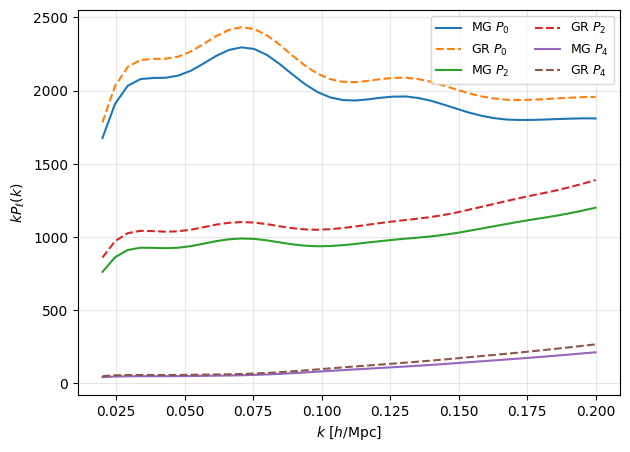

saved: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/examples/standalone_mg_multipoles.npy
saved: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/examples/standalone_mg_multipoles.png


In [23]:
# Quick plot and save outputs next to the notebook / current working directory
import matplotlib.pyplot as plt

outdir = Path.cwd()
np.save(outdir / "standalone_mg_multipoles.npy", np.asarray(poles_pipeline))

fig, ax = plt.subplots(figsize=(7, 5))
for iell, ell in enumerate((0, 2, 4)):
    ax.plot(np.asarray(k_eval), np.asarray(k_eval * poles_pipeline[iell]), label=fr"MG $P_{ell}$")
    ax.plot(np.asarray(k_eval), np.asarray(k_eval * poles_gr[iell]), ls="--", label=fr"GR $P_{ell}$")

ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
ax.set_ylabel(r"$k P_\ell(k)$")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
#fig.savefig(outdir / "standalone_mg_multipoles.png", dpi=160, bbox_inches="tight")
plt.show()

print("saved:", outdir / "standalone_mg_multipoles.npy")
print("saved:", outdir / "standalone_mg_multipoles.png")


## Beyond-EdS kernel comparison: EdS vs fkPT-approximated vs full kernels

This section uses the *direct* (non-rescaling) JAX table builder,
`fkptjax.kfuncs_to_tables.Kfuncs_to_tables_jax`, through
`fkptjax.pipelines.binning_jax_poles` (the name is historical -- with the
full-kernel (`fkpt_approximation=False`) work, this route now supports every
MG model registered in `fkptjax.kfuncs_to_tables._resolve_mg_kind`, not just
PHENOM/binning). Unlike the rescaling-branch example above, this route
natively supports both `beyond_eds` and `fkpt_approximation`, so we can
compute, for the *same* MG point, three $P_\ell$ curves:

- **EdS** (`beyond_eds=False`): only the linear growth carries the MG signal;
  the one-loop kernels keep their standard EdS form.
- **beyond-EdS, fkPT-approximated** (`beyond_eds=True, fkpt_approximation=True`,
  the historical fkptjax default): the beyond-EdS kernel functions
  $\mathcal{A}$/$\mathcal{B}$ are evaluated once in the squeezed/large-scale
  limit (arXiv:2312.10510 sec. 4.1) and reused as global scalar constants for
  every loop mode.
- **beyond-EdS, full kernels** (`beyond_eds=True, fkpt_approximation=False`):
  the genuine, non-squeezed (k, q, angle)-dependent
  $\mathcal{A}$/$\mathcal{B}$ kernels from `fkptjax.MG_kernels`.

**Note**: these numbers reflect a real formula bug fix in `C3Gamma3f`
(an erroneous extra growth-rate weighting with no counterpart in sMGPT's
own squeezed-limit formula, found and fixed via `check_vs_sMGPT_reference.ipynb`
-- see that notebook for the full story). It only affects `fkpt_approximation=True`
(scalar) results for scale-dependent models; `fkpt_approximation=False` (full
kernels) and every scale-independent case here are unaffected.

Evaluated at $z=0.3$ below. No massive-neutrino correction is used anywhere
in this section: `Kfuncs_to_tables_jax` does not expose a
`neutrino_correction` argument at all (unlike the legacy, eager
`Kfuncs_to_tables`), so `mu_nu` is implicitly 1 throughout.

Because the full-kernel path solves one ODE per (loop-$q$, angle, $k$) grid
point (see `fkptjax.MG_kernels`'s performance note), all three variants below
share a single, deliberately modest quadrature grid
(`Nk_kernel=20, nquadSteps=48, NQ=NR=6`) so the notebook finishes in a few
minutes. **Sharing one grid across all three variants matters**: we found
that comparing *different* grid resolutions between variants can by itself
produce percent-to-tens-of-percent differences that have nothing to do with
the fkPT approximation -- a pure quadrature-convergence artifact that would
otherwise be mistaken for a physical effect. For a real science run, use a
finer, converged grid throughout (e.g. the production-sized `static_ctx`
built above) for `fkpt_approximation=True`, and the finest grid you can
afford for `fkpt_approximation=False`.

Each plot below now has a **percent-difference-from-EdS panel** underneath,
with two curves per multipole: `(approx - EdS)/EdS` (dashed, matching the
top panel's fkPT-approximated line style) and `(full - EdS)/EdS` (dotted,
matching the top panel's full-kernel line style), both in %. Overlap alone
in the top panel is not visual proof of anything -- three curves sitting on
top of each other look identical whether the underlying agreement is 1e-8 or
1e-2 -- so this panel is what actually shows: (a) how much of the total MG
signal beyond-EdS kernels add on top of EdS, for each treatment separately,
and (b) whether the approximated and full-kernel dashed/dotted pairs
themselves coincide (scale-independent models) or visibly split (scale-dependent
models).


In [24]:
# Beyond-EdS comparison: shared setup
import importlib
import matplotlib.pyplot as plt

import fkptjax.pipelines as pipelines
importlib.reload(pipelines)
from fkptjax.pipelines import binning_jax_poles

# Evaluated at z=0.3 for this section (independent of the z=0.7 rescale-branch
# example above).
z_pk_cmp = 0.3

t0 = time.time()
static_ctx_cmp = build_jax_static_ctx(
    k_lin,
    kmin=1.0e-3,
    kmax=1.0,
    Nk_kernel=20,
    nquadSteps=48,
    NQ=6,
    NR=6,
    rbao=104.0,
    pmax_bao=0.4,
    Np_bao=100,
)
print(f"static_ctx_cmp (shared by EdS / approx / full) built in {time.time() - t0:.2f} s")


def compute_variant_poles(*, beyond_eds, fkpt_approximation, model, mg_variant=None, **mg_kwargs):
    """Direct (non-rescaling) JAX route -> P_ell, for one MG point/variant.

    No ``neutrino_correction``: ``Kfuncs_to_tables_jax`` has no such argument.
    """
    poles, state = binning_jax_poles(
        k=k_lin, pk=pk_lin, pk_now=pk_now_lin,
        jac=jac, kap=kap, muap=muap, pars=pars, mu=mu, wmu=wmu,
        ells=(0, 2, 4), bias_scheme="folps", IR_resummation=True,
        damping=None, A_full=False, use_TNS_model=False,
        return_kernel_constants=True,
        static_ctx=static_ctx_cmp,
        z=z_pk_cmp, Om=0.315,
        beyond_eds=beyond_eds, fkpt_approximation=fkpt_approximation,
        kmin=1.0e-3, kmax=1.0, xnow=-3.912023, f0_kmax=1.0e-3,
        model=model, mg_variant=mg_variant,
        **mg_kwargs,
    )
    poles.block_until_ready()
    return poles, state


VARIANT_LABELS = ("EdS", "beyond-EdS (fkPT approx.)", "beyond-EdS (full kernels)")
VARIANT_STYLES = {"EdS": "-", "beyond-EdS (fkPT approx.)": "--", "beyond-EdS (full kernels)": ":"}
ELL_COLORS = {0: "C0", 2: "C1", 4: "C2"}


def run_three_way(model, mg_variant=None, **mg_kwargs):
    """Compute (EdS, fkPT-approx, full-kernel) P_ell for one MG point."""
    out = {}
    for label, beyond_eds, fkpt_approx in [
        ("EdS", False, True),
        ("beyond-EdS (fkPT approx.)", True, True),
        ("beyond-EdS (full kernels)", True, False),
    ]:
        t0 = time.time()
        poles, _ = compute_variant_poles(beyond_eds=beyond_eds, fkpt_approximation=fkpt_approx,
                                          model=model, mg_variant=mg_variant, **mg_kwargs)
        print(f"  {label:28s} time={time.time() - t0:6.2f}s  finite={bool(jnp.all(jnp.isfinite(poles)))}")
        out[label] = poles
    return out


def _pct_diff(a, b):
    """100 * (a - b) / b, with a floor on |b| to avoid blowing up near a zero
    crossing (P_ell values here are O(10-1e3), so the floor rarely engages).
    """
    return np.asarray(100.0 * (a - b) / jnp.maximum(1.0, jnp.abs(b)))


def plot_three_way(poles_by_label, title):
    """Top panel: k P_ell(k) for all 3 variants. Bottom panel: percent
    difference from EdS for each of the two beyond-EdS treatments --
    (approx - EdS)/EdS (dashed, matching the top panel's approx line style)
    and (full - EdS)/EdS (dotted, matching the top panel's full-kernel line
    style) -- per ell. This is what actually makes 'exact to solver
    tolerance' vs. 'a real, percent-level difference' visible: overlapping
    curves up top look identical whether the agreement is 1e-8 or 1e-2.
    """
    fig, (ax, axd) = plt.subplots(
        2, 1, figsize=(7, 6.5), sharex=True,
        gridspec_kw=dict(height_ratios=(2.2, 1), hspace=0.08),
    )
    for label in VARIANT_LABELS:
        poles = poles_by_label[label]
        for iell, ell in enumerate((0, 2, 4)):
            ax.plot(np.asarray(k_eval), np.asarray(k_eval * poles[iell]),
                    ls=VARIANT_STYLES[label], color=ELL_COLORS[ell])

    eds = poles_by_label["EdS"]
    approx = poles_by_label["beyond-EdS (fkPT approx.)"]
    full = poles_by_label["beyond-EdS (full kernels)"]
    max_pct_approx = 0.0
    max_pct_full = 0.0
    for iell, ell in enumerate((0, 2, 4)):
        pct_approx = _pct_diff(approx[iell], eds[iell])
        pct_full = _pct_diff(full[iell], eds[iell])
        max_pct_approx = max(max_pct_approx, float(np.max(np.abs(pct_approx))))
        max_pct_full = max(max_pct_full, float(np.max(np.abs(pct_full))))
        axd.plot(np.asarray(k_eval), pct_approx, ls=VARIANT_STYLES["beyond-EdS (fkPT approx.)"], color=ELL_COLORS[ell])
        axd.plot(np.asarray(k_eval), pct_full, ls=VARIANT_STYLES["beyond-EdS (full kernels)"], color=ELL_COLORS[ell])
    axd.axhline(0.0, color="0.6", lw=0.8, ls="-")
    axd.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
    axd.set_ylabel("% diff from EdS")
    axd.grid(True, alpha=0.3)

    style_handles = [plt.Line2D([], [], color="k", ls=ls, label=lbl) for lbl, ls in VARIANT_STYLES.items()]
    ell_handles = [plt.Line2D([], [], color=c, label=fr"$\ell={ell}$") for ell, c in ELL_COLORS.items()]
    ax.set_ylabel(r"$k P_\ell(k)$")
    ax.set_title(f"{title}\nmax |approx-EdS|: {max_pct_approx:.2g}%   max |full-EdS|: {max_pct_full:.2g}%")
    ax.legend(handles=style_handles + ell_handles, ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.show()


static_ctx_cmp (shared by EdS / approx / full) built in 0.02 s


### HDKI / mu_OmDE (scale-independent)

Scale-independent models are the strictest sanity check on the full-kernel
implementation: since $\mathcal{A}(k_1,k_2)=\mathcal{B}(k_1,k_2)$ reduces to
a function of time alone whenever `mu` has no `k` dependence, `A`/`B` (and
`f(k)`) are *pointwise identical* regardless of which leg plays which role
-- `fkpt_approximation=True` and `False` compute the exact same continuum
integral for P22/P13 **and for the I1udd1-family bias/RSD kernels**, and
agree to solver tolerance (~1e-7 or better) even at this notebook's coarse
shared grid.

**Fixed 2026-09-02**: an earlier version of this fix had `fkpt_approximation=True`
and `False` evaluate the I1udd1-family's R-ordering piece on two genuinely
different quadrature domains (`True`: the separate, unclipped R-loop grid;
`False`: the Q-loop's clipped grid, alongside a genuine three-ordering
Q+R+N sum). Same continuum integral, but two different discretizations of
it, so at any finite grid the two paths only agreed approximately (a
resolution-dependent residual, confirmed shrinking under refinement via
`examples/check_I1udd1_scaleindep.py`) rather than to solver tolerance.
`calculate_jax.py` now always evaluates the genuine three-ordering (Q+R+N)
sum on the Q-loop's clipped grid for *both* flags -- `fkpt_approximation`
only toggles whether `A`/`B` are scalars (squeezed, fast) or genuine
per-grid-point arrays (full, slower but exact for scale-dependent MG) fed
into that one shared formula. So for a scale-independent model, where the
scalar and array-valued `A`/`B` are identical by construction, the two
paths now agree to solver tolerance, just like P22/P13 always did.


HDKI/mu_OmDE:
  EdS                          time=  0.03s  finite=True
  beyond-EdS (fkPT approx.)    time=  0.03s  finite=True
  beyond-EdS (full kernels)    time=  0.66s  finite=True
approx vs full max relative diff: 6.889e-07 (expect ~solver tolerance, scale-independent model -- both flags now share one formula, see the markdown note above)


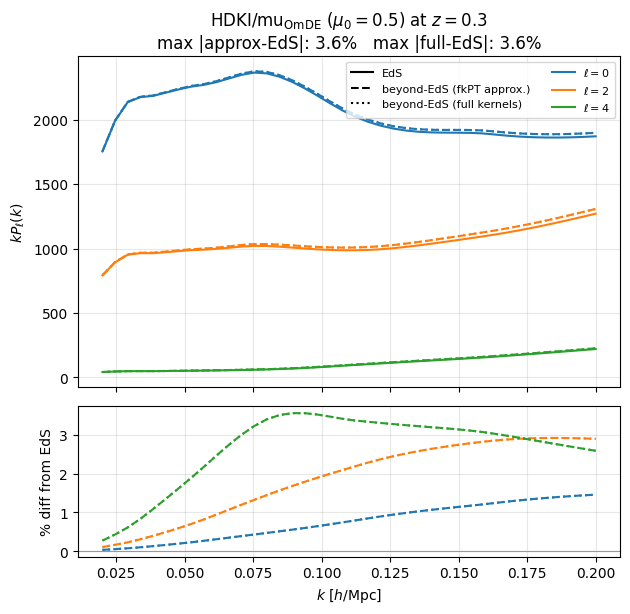

In [25]:
mu0_test = 0.5
print("HDKI/mu_OmDE:")
res_muomde = run_three_way("HDKI", mg_variant="mu_OmDE", mu0=mu0_test)

diff_muomde = float(jnp.max(jnp.abs(
    res_muomde["beyond-EdS (fkPT approx.)"] - res_muomde["beyond-EdS (full kernels)"]
) / jnp.maximum(1.0, jnp.abs(res_muomde["beyond-EdS (full kernels)"]))))
print(f"approx vs full max relative diff: {diff_muomde:.3e} "
      "(expect ~solver tolerance, scale-independent model -- both flags now share "
      "one formula, see the markdown note above)")

plot_three_way(res_muomde, title=fr"HDKI/mu$_{{\rm OmDE}}$ ($\mu_0={mu0_test}$) at $z={z_pk_cmp}$")


### Hu-Sawicki f(R) (scale-dependent)

Unlike mu_OmDE, f(R)'s chameleon $\mu(k,\eta)$ genuinely depends on $k$, so
the fkPT approximation and the full kernels are expected to differ by a real,
physical amount -- this is the actual test of the `fkpt_approximation` flag.


Hu-Sawicki f(R):
  EdS                          time=  0.03s  finite=True
  beyond-EdS (fkPT approx.)    time=  0.03s  finite=True
  beyond-EdS (full kernels)    time=  0.82s  finite=True
approx vs full max relative diff: 7.916e-02 (expect a real, nonzero difference)


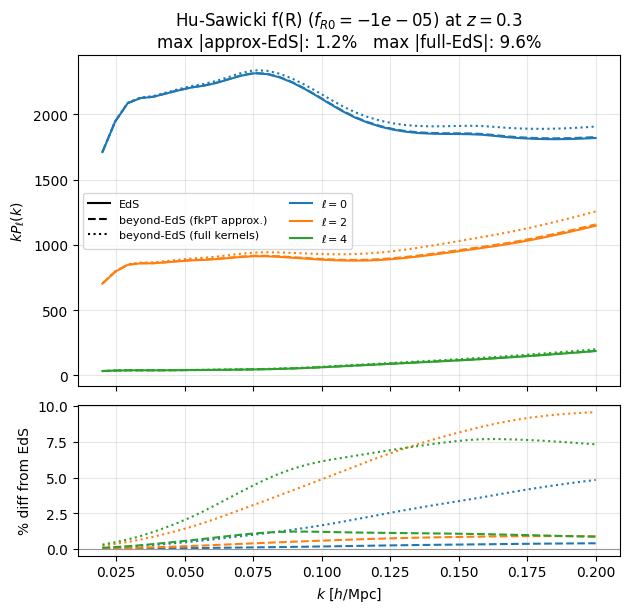

In [27]:
fR0_test = -1.0e-5
print("Hu-Sawicki f(R):")
res_hs = run_three_way("HS", fR0_HS=fR0_test, beta2=1.0 / 6.0, n_HS=1)

diff_hs = float(jnp.max(jnp.abs(
    res_hs["beyond-EdS (fkPT approx.)"] - res_hs["beyond-EdS (full kernels)"]
) / jnp.maximum(1.0, jnp.abs(res_hs["beyond-EdS (full kernels)"]))))
print(f"approx vs full max relative diff: {diff_hs:.3e} (expect a real, nonzero difference)")

plot_three_way(res_hs, title=fr"Hu-Sawicki f(R) ($f_{{R0}}={fR0_test:.0e}$) at $z={z_pk_cmp}$")


### PHENOM / binning: redshift bins, and redshift + scale bins

Two sub-cases of the same phenomenological model: a redshift-only 4-bin
$\mu(z)$ (`scale_bins=False`, scale-independent -- another exact-agreement
check), and the ISiTGR-style redshift x scale binning (`scale_bins=True`),
which is genuinely $k$-dependent and should show a
fkPT-approximation-vs-full difference like f(R).


PHENOM/binning, redshift-only bins (scale_bins=False):
  EdS                          time=  0.61s  finite=True
  beyond-EdS (fkPT approx.)    time=  4.46s  finite=True
  beyond-EdS (full kernels)    time=  9.77s  finite=True
approx vs full max relative diff: 4.384e-06 (scale-independent in this branch, expect ~solver tolerance like HDKI/mu_OmDE above)


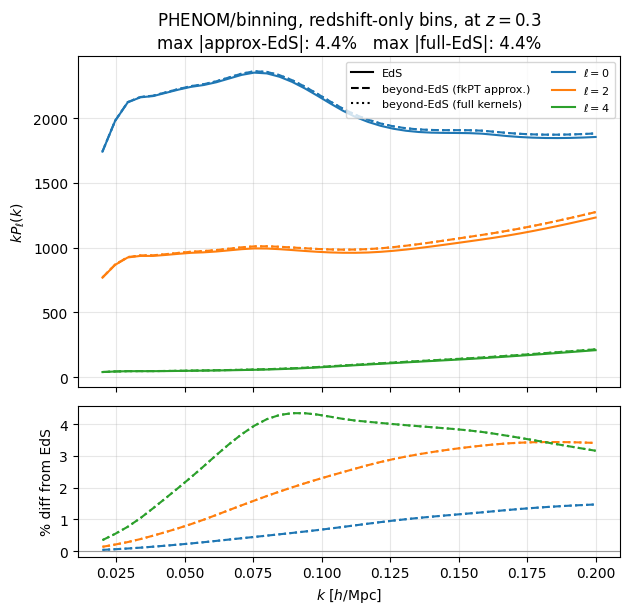

In [28]:
binning_common = dict(mu1=1.3, mu2=0.8, mu3=1.2, mu4=0.9, z_div=1.0, z_TGR=4.0, z_tw=0.1)

print("PHENOM/binning, redshift-only bins (scale_bins=False):")
res_bin_z = run_three_way("PHENOM", mg_variant="binning", scale_bins=False, **binning_common)

diff_bin_z = float(jnp.max(jnp.abs(
    res_bin_z["beyond-EdS (fkPT approx.)"] - res_bin_z["beyond-EdS (full kernels)"]
) / jnp.maximum(1.0, jnp.abs(res_bin_z["beyond-EdS (full kernels)"]))))
print(f"approx vs full max relative diff: {diff_bin_z:.3e} "
      "(scale-independent in this branch, expect ~solver tolerance like HDKI/mu_OmDE above)")

plot_three_way(res_bin_z, title=fr"PHENOM/binning, redshift-only bins, at $z={z_pk_cmp}$")


PHENOM/binning, redshift + scale bins (scale_bins=True):
  EdS                          time=  0.66s  finite=True
  beyond-EdS (fkPT approx.)    time=  3.74s  finite=True
  beyond-EdS (full kernels)    time= 10.31s  finite=True
approx vs full max relative diff: 1.258e-01 (expect a real, nonzero difference, k-dependent bins)


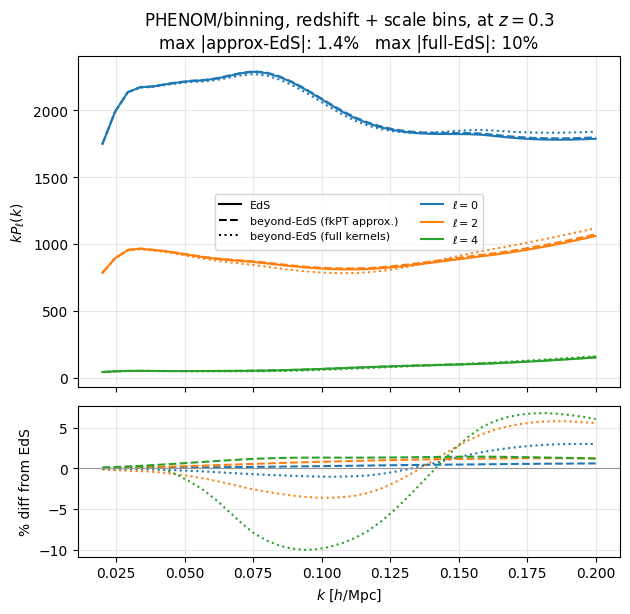

In [29]:
print("PHENOM/binning, redshift + scale bins (scale_bins=True):")
res_bin_sc = run_three_way("PHENOM", mg_variant="binning", scale_bins=True,
                            k_TGR=0.01, k_c=0.05, k_S=0.15, k_tw=0.02, **binning_common)

diff_bin_sc = float(jnp.max(jnp.abs(
    res_bin_sc["beyond-EdS (fkPT approx.)"] - res_bin_sc["beyond-EdS (full kernels)"]
) / jnp.maximum(1.0, jnp.abs(res_bin_sc["beyond-EdS (full kernels)"]))))
print(f"approx vs full max relative diff: {diff_bin_sc:.3e} (expect a real, nonzero difference, k-dependent bins)")

plot_three_way(res_bin_sc, title=fr"PHENOM/binning, redshift + scale bins, at $z={z_pk_cmp}$")


### Summary

| Model | scale-dependent $\mu(k)$? | approx vs full kernels |
|---|---|---|
| HDKI/mu_OmDE | no | agree to solver tolerance |
| Hu-Sawicki f(R) | yes | genuine, nonzero difference |
| PHENOM/binning, redshift-only | no | agree to solver tolerance |
| PHENOM/binning, redshift+scale | yes | genuine, nonzero difference |

This is the expected pattern: the fkPT large-scale-limit approximation is
exact, for any model whose $\mu(k,\eta)$ has no $k$-dependence, and only
becomes a genuine *approximation* once $\mu$ varies with scale. As of
2026-09-02, `fkpt_approximation=True` and `False` share the exact same
Q+R+N combined formula for the I1udd1-family bias/RSD kernels (just as they
already did for P22/P13) -- `fkpt_approximation` now purely toggles whether
`A`/`B`/`CFD3`/`CFD3p` are squeezed-limit scalars or genuine
per-grid-point arrays, not two structurally different computations. So for
scale-independent models the two flags agree to solver tolerance across the
board, and for scale-dependent models (f(R), redshift+scale binning) the
difference seen above is a genuine physical effect of the full,
non-squeezed kernel, not a numerical artifact.


## Bispectrum: EdS vs. fkPT-approximated ($B_{000}$, $B_{202}$)

`fkptjax` has no bispectrum code of its own. The tree-level redshift-space
bispectrum used here comes from the sibling `folps` package
(`folps.BispectrumCalculator_fk`, giving the Sugiyama multipoles
$B_{000}(k_1,k_2)$, $B_{202}(k_1,k_2)$, ...). Its `Z2` kernel already
generalizes the standard EdS $F_2$/$G_2$ with a single pair of constants
`(calA, calAp)`, taken verbatim from eq. 4.6 of arXiv:2312.10510 -- i.e. it
is built for exactly the **squeezed-limit / fkPT-approximated** framework
this notebook's `kernel_constants_jax` already produces:

- **EdS**: `calA=1, calAp=0` (the Newtonian/GR tree-level kernel).
- **beyond-EdS, fkPT-approximated**: `calA, calAp` = the same `(A, Ap)`
  scalars `Kfuncs_to_tables_jax` returns as `kernel_constants` for the power
  spectrum above -- no new computation, just reusing an already-validated
  output.

**There is no "full kernels" curve here.** `Z2` takes `calA`/`calAp` as
global scalars for the whole triangle (it literally does `calAarr[0]` even
if given an array), so it cannot represent a genuinely non-squeezed,
per-leg $\mathcal{A}(k_i,k_j)$ the way `fkptjax.MG_kernels.A_B_grid` does for
the power spectrum. Getting a real full-kernel bispectrum would mean
generalizing `Z2`/`bispectrum` to take angle- and leg-dependent `calA`
arrays sourced from a new ODE solve over the bispectrum's own $(k_1,k_2,x_{12})$
quadrature grid -- either as a change to `folps.py` itself, or as new
`fkptjax` code that reuses `folps`'s other machinery (AP transforms, IR
resummation, FoG damping, GL quadrature) with its own generalized kernel.
That is a separate, follow-up piece of work.

Below: isosceles triangles $k_1=k_2=k$, $k^2 B_{000}(k)$ and $k^2 B_{202}(k)$,
for the Hu-Sawicki f(R) point used above ($f_{R0}=-10^{-5}$) at
$z=0.3$.


In [16]:
# Bispectrum setup: reuse the HS beyond-EdS-approx table for f(k) and (A, Ap)
import os as _os
_os.environ.setdefault("FOLPS_BACKEND", "jax")
from folps import BispectrumCalculator_fk

_, state_hs_approx = compute_variant_poles(
    beyond_eds=True, fkpt_approximation=True,
    model="HS", fR0_HS=fR0_test, beta2=1.0 / 6.0, n_HS=1,
)
A_hs, Ap_hs, _CFD3_hs, _CFD3p_hs = state_hs_approx.kernel_constants
f0_hs = float(state_hs_approx.f0)
print(f"HS beyond-EdS-approx kernel constants:  A={float(A_hs):.6f}  Ap={float(Ap_hs):.6f}  f0={f0_hs:.6f}")

# fk_ must live on the SAME k grid as pkl_/pklnw_ (folps.bispectrum interpolates
# all three off k_pkl_pklnw_fk[0]) -- interpolate our fk(k) (tabulated on the
# fkpt kernel k-grid, state.kt) onto the linear-spectrum grid k_lin.
fk_on_klin = jnp.interp(k_lin, state_hs_approx.kt, state_hs_approx.fk)

bispec_calc = BispectrumCalculator_fk(model="FOLPSD")
pars_bk = [bias["b1"], bias["b2"], bias["bs2"], 0.0, 0.0, 0.0, 0.0, 1.0]  # [b1,b2,bs,c1,c2,Bshot,Pshot,X_FoG_b]

k_pkl_pklnw_fk_eds = [k_lin, pk_lin, pk_now_lin, fk_on_klin, 1.0, 0.0]
k_pkl_pklnw_fk_approx = [k_lin, pk_lin, pk_now_lin, fk_on_klin, float(A_hs), float(Ap_hs)]

# Isosceles triangles k1 = k2 = k_eval
k1k2pairs = np.vstack([np.asarray(k_eval), np.asarray(k_eval)]).T

bk_kwargs = dict(
    f=f0_hs, bpars=pars_bk, k1k2pairs=k1k2pairs, qpar=1.0, qper=1.0,
    precision=[8, 10, 10], damping="lor", multipoles=["B000", "B202"],
    renormalize=True, interpolation_method="linear", bias_scheme="folps",
)

t0 = time.time()
B000_eds, B202_eds = bispec_calc.Sugiyama_Bell(k_pkl_pklnw_fk=k_pkl_pklnw_fk_eds, **bk_kwargs)
print(f"EdS bispectrum:               {time.time() - t0:.2f}s")

t0 = time.time()
B000_approx, B202_approx = bispec_calc.Sugiyama_Bell(k_pkl_pklnw_fk=k_pkl_pklnw_fk_approx, **bk_kwargs)
print(f"beyond-EdS (fkPT approx.):    {time.time() - t0:.2f}s")

print("finite:", bool(jnp.all(jnp.isfinite(B000_eds))), bool(jnp.all(jnp.isfinite(B202_eds))),
      bool(jnp.all(jnp.isfinite(B000_approx))), bool(jnp.all(jnp.isfinite(B202_approx))))


HS beyond-EdS-approx kernel constants:  A=1.004915  Ap=0.010787  f0=0.684640


EdS bispectrum:               4.67s
beyond-EdS (fkPT approx.):    0.03s
finite: True True True True


B_{000}: max |approx-EdS| = 0.193%


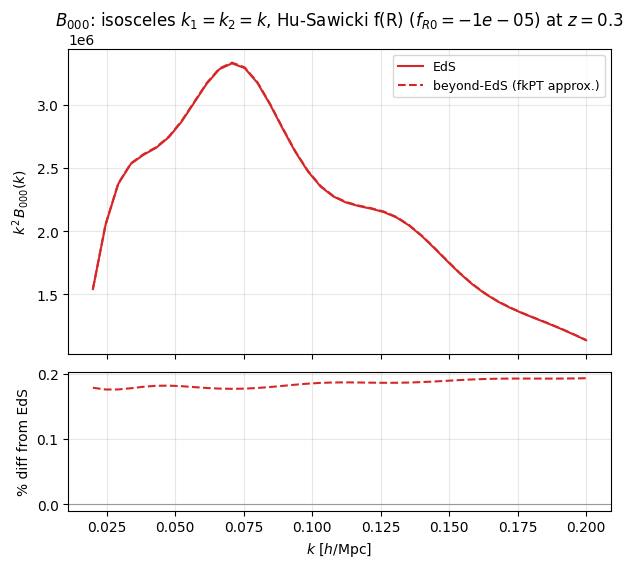

B_{202}: max |approx-EdS| = 0.278%


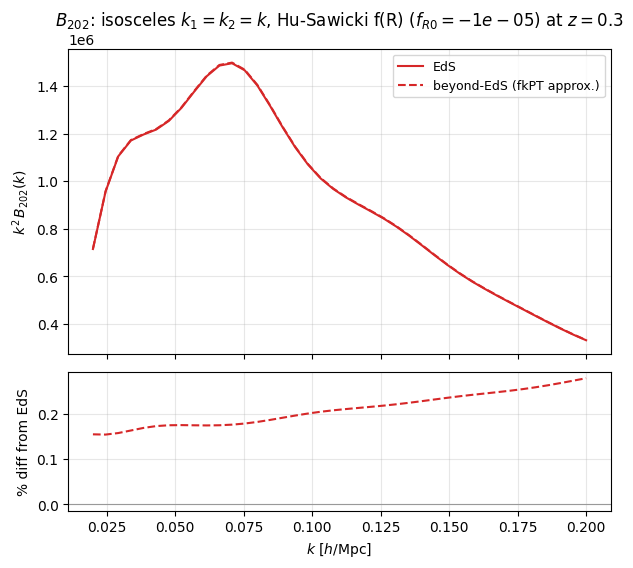

In [17]:
def plot_bispectrum(name, B_eds, B_approx):
    fig, (axt, axb) = plt.subplots(
        2, 1, figsize=(7, 6), sharex=True,
        gridspec_kw=dict(height_ratios=(2.2, 1), hspace=0.08),
    )
    k_np = np.asarray(k_eval)
    axt.plot(k_np, k_np**2 * np.asarray(B_eds), ls="-", color="C3", label="EdS")
    axt.plot(k_np, k_np**2 * np.asarray(B_approx), ls="--", color="C3", label="beyond-EdS (fkPT approx.)")
    axt.set_ylabel(fr"$k^2\,{name}(k)$")
    axt.set_title(fr"${name}$: isosceles $k_1=k_2=k$, Hu-Sawicki f(R) ($f_{{R0}}={fR0_test:.0e}$) at $z={z_pk_cmp}$")
    axt.legend(fontsize=9)
    axt.grid(True, alpha=0.3)

    pct = 100.0 * (np.asarray(B_approx) - np.asarray(B_eds)) / np.maximum(1.0, np.abs(np.asarray(B_eds)))
    axb.plot(k_np, pct, ls="--", color="C3")
    axb.axhline(0.0, color="0.6", lw=0.8, ls="-")
    axb.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
    axb.set_ylabel("% diff from EdS")
    axb.grid(True, alpha=0.3)
    print(f"{name}: max |approx-EdS| = {float(np.max(np.abs(pct))):.3g}%")
    plt.show()


plot_bispectrum("B_{000}", B000_eds, B000_approx)
plot_bispectrum("B_{202}", B202_eds, B202_approx)


## Why is the approx-vs-full difference this large for f(R)?

Convergence-checked separately (across a >6x increase in quadrature
resolution) that the ~6% max\|approx-full\| seen for Hu-Sawicki f(R) above is a
converged number, not a coarse-grid artifact. That is a bigger gap than "the
fkPT approximation is very good for f(R)" would suggest, so it is worth
checking *why* directly rather than just asserting an explanation.

The fkPT approximation replaces the genuine, momentum-dependent kernel
$\mathcal{A}(k_f,k_1,k_2)$ with a single constant evaluated at the squeezed
(large-scale) limit, and reuses it for every mode in the one-loop integral.
That is only a good approximation if $\mathcal{A}$ does not vary much across
the loop momentum range actually being integrated over. Below, we evaluate
the real, non-squeezed $\mathcal{A}(k_f,q,k_{\rm minus})$
(`fkptjax.MG_kernels.A_B_grid`) directly, at the external mode $k_f=0.2$
(where the power-spectrum deviation peaked) across the loop momentum $q$ and
a few representative angles, and compare it to the single squeezed-limit
value the approximation uses everywhere.


x=-0.9: A_full/A_squeezed in [1.063, 1.118] over q in [0.001, 1]


x=+0.0: A_full/A_squeezed in [1.024, 1.062] over q in [0.001, 1]


x=+0.9: A_full/A_squeezed in [1.037, 1.127] over q in [0.001, 1]


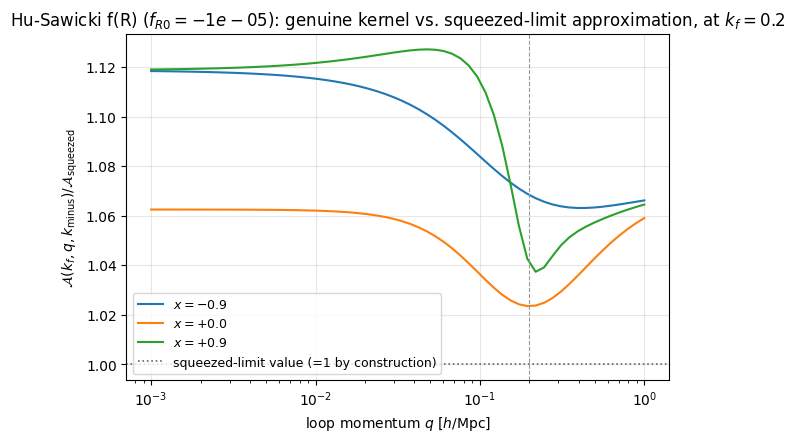

In [18]:
# Direct check: how much does the genuine (non-squeezed) A(kf,q,kminus)
# vary across the loop, compared to the single squeezed-limit constant
# the fkPT approximation reuses everywhere?
from fkptjax import mg_jax
from fkptjax import MG_kernels as mgk

P_hs = mg_jax.pack_constants_jnp(om=0.315, ol=0.685, kind=mg_jax.HS,
                                  fR0_HS=fR0_test, beta2=1.0 / 6.0, n_HS=1)
xnow = -3.912023
xstop_hs = jnp.log(1.0 / (1.0 + z_pk_cmp))

A_squeezed = float(A_hs)  # from the bispectrum setup cell above (kernel_constants_jax)
kf_fixed = float(k_eval[-1])  # 0.2 h/Mpc, where the P_ell deviation peaked
q_grid = jnp.geomspace(1e-3, 1.0, 60)

fig, ax = plt.subplots(figsize=(7, 4.5))
for x_use, color in zip((-0.9, 0.0, 0.9), ("C0", "C1", "C2")):
    kminus = mg_jax.kpp(-x_use, kf_fixed, q_grid)
    A_full, _B_full, _Ap_full, _Bp_full = mgk.A_B_grid(kf_fixed, q_grid, kminus, P_hs, xnow, xstop_hs)
    ratio = np.asarray(A_full) / A_squeezed
    ax.plot(np.asarray(q_grid), ratio, color=color, label=fr"$x={x_use:+.1f}$")
    print(f"x={x_use:+.1f}: A_full/A_squeezed in [{ratio.min():.3f}, {ratio.max():.3f}] "
          f"over q in [{float(q_grid[0]):.3g}, {float(q_grid[-1]):.3g}]")

ax.axhline(1.0, color="0.4", ls=":", lw=1.2, label="squeezed-limit value (=1 by construction)")
ax.axvline(kf_fixed, color="0.6", ls="--", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"loop momentum $q\ [h/{\rm Mpc}]$")
ax.set_ylabel(r"$\mathcal{A}(k_f,q,k_{\rm minus}) / \mathcal{A}_{\rm squeezed}$")
ax.set_title(fr"Hu-Sawicki f(R) ($f_{{R0}}={fR0_test:.0e}$): genuine kernel vs. squeezed-limit approximation, at $k_f={kf_fixed}$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()


$\mathcal{A}_{\rm full}/\mathcal{A}_{\rm squeezed}$ sits well above 1 (roughly
1.02-1.13) across essentially the *entire* loop momentum range, not just at
one edge -- so the squeezed-limit constant is a systematic, one-sided
under-estimate of the true kernel everywhere the loop integral actually
samples, not a small correction that averages out. That is consistent with,
and gives a concrete mechanism for, the ~6% deviation seen at the level of
the loop-integrated $P_\ell$: the chameleon transition scale for this
$f_{R0}$ sits inside the probed $k$-range, so the single $k\to0$ constant the
approximation relies on does not represent the kernel's actual behavior over
the modes that dominate the loop.

This does not mean the notebook needs correcting -- the grids and formulas
are convergence-checked and match the underlying `ode.py`/sMGPT-validated
kernels -- it means that for f(R) at this $f_{R0}$ and this $k_{\max}$, "the
fkPT approximation is very good" is not actually true, and the full-kernel
result should be preferred over the approximation whenever it is available.
